# Laboratorio 1 — Construí tu propio motor de *autograd*

### Fundamentos matemáticos del aprendizaje profundo · Clase 1
**Inteligencia Artificial Generativa Avanzada y Sistemas Multi Agente** — Licenciatura en Tecnología Digital, UTDT

---

En este laboratorio vas a construir, **desde cero y en unas cien líneas de Python**, un motor de **diferenciación automática en modo reverso**: el mismo mecanismo que usan PyTorch, JAX y TensorFlow para calcular gradientes. Y con él vas a **entrenar una red neuronal** de verdad.

Está basado en **micrograd**, de Andrej Karpathy (licencia MIT).

## Objetivos de aprendizaje
Al terminar vas a poder:
- implementar la clase `Value`, el **nodo** de un grafo de cómputo;
- programar el **forward** (que a la vez *construye* el grafo);
- implementar el **backward** (modo reverso) y verificarlo con *gradient check*;
- armar `Neuron`, `Layer` y `MLP` sobre tu `Value`;
- escribir el **bucle de entrenamiento** y ver bajar la pérdida.

## Cómo trabajar en esta notebook
- Vas a completar código **solo** entre las marcas
  `### EMPEZÁ TU CÓDIGO ACÁ ###` y `### TERMINÁ TU CÓDIGO ACÁ ###`, reemplazando los `None`.
- **No modifiques** nada fuera de esas zonas (en particular, no toques las celdas de **TEST**).
- Después de cada ejercicio hay una celda de **test** y un bloque **Salida esperada** para que verifiques.
- Corré las celdas **en orden**, de arriba hacia abajo.

> 💡 A lo largo del lab vamos a ir **agregando métodos** a la clase `Value` de a uno (con `Value.metodo = ...`). Es una forma cómoda de trabajar por partes; el resultado es exactamente el mismo que si escribieras la clase completa de una vez.


## Contenido
- [0 - Preparación](#0)
- [1 - El nodo del grafo: `Value`](#1)  ·  *Ejercicio 1 (`__add__`)*, *Ejercicio 2 (`__mul__`)*
- [2 - Activaciones y el barrido *backward*](#2)  ·  *Ejercicio 3 (`tanh`)*, *Ejercicio 4 (`backward`)*
- [3 - De neurona a red](#3)  ·  *Ejercicio 5 (`Neuron.__call__`)*
- [4 - El bucle de entrenamiento](#4)  ·  *Ejercicio 6 (`train`)*
- [5 - (Opcional) Extendé el motor](#5)  ·  *Ejercicio 7 (`exp`)*


<a name='0'></a>
## 0 - Preparación

Importamos lo mínimo: `math` (para `tanh`/`exp`), `random` (para inicializar pesos) y `matplotlib` (para graficar la curva de pérdida). Fijamos una semilla para que los resultados sean **reproducibles**. Corré esta celda tal cual.
Tambien agregamos una funcion para visualizar el grafo

In [1]:
import math
import random
import matplotlib.pyplot as plt

random.seed(1337)   # reproducibilidad
%matplotlib inline
print("Listo. Versiones y semilla OK.")

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle, FancyArrowPatch

def draw_graph(root, names=None):
    """Grafo de computo con solo matplotlib. Columna = distancia a la salida,
    asi cada operando cae al lado de la operacion que lo consume."""
    id2name = {id(v): k for k, v in (names or {}).items()}
    C = {"box":"#ECFDF5","eb":"#0F766E","root":"#FDE68A","op":"#B45309",
         "ink":"#0F172A","edge":"#94A3B8","muted":"#475569"}

    # 1) recolectar nodos y aristas
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for ch in v._prev:
                edges.add((ch, v)); build(ch)
    build(root)

    # 2) nivel = distancia (mas larga) HASTA la raiz  -> define la columna
    parents = {v: set() for v in nodes}
    for a, b in edges: parents[a].add(b)
    level = {}
    def lv(v):
        if v in level: return level[v]
        level[v] = 0 if v is root else 1 + max(lv(p) for p in parents[v])
        return level[v]
    for v in nodes: lv(v)

    # 3) posicion vertical por baricentro de los hijos (de izquierda a derecha)
    layers = {}
    for v in nodes: layers.setdefault(level[v], []).append(v)
    ypos = {}
    for L in sorted(layers, reverse=True):
        layer = layers[L]
        def bary(v):
            ch = list(v._prev)
            return sum(ypos[c] for c in ch)/len(ch) if ch and all(c in ypos for c in ch) else 0.0
        layer.sort(key=lambda v: (bary(v), id(v)))
        n = len(layer)
        for i, v in enumerate(layer):
            ypos[v] = (i - (n-1)/2) * 1.5
    XS = 2.7
    pos = {v: (-level[v]*XS, ypos[v]) for v in nodes}   # raiz a la derecha (x=0)

    # 4) lienzo
    xs = [p[0] for p in pos.values()]; ys = [p[1] for p in pos.values()]; W, H = 1.75, 0.92
    fig, ax = plt.subplots(figsize=(max(6, (max(xs)-min(xs))/2.0+3.2),
                                     max(3, (max(ys)-min(ys))/1.5+2.0)), dpi=140)
    ax.set_xlim(min(xs)-1.4, max(xs)+1.5); ax.set_ylim(min(ys)-1.2, max(ys)+1.2); ax.axis("off")

    def arrow(x1, y1, x2, y2):
        conn = "arc3,rad=0.1" if abs(x2-x1) > 1.4*XS else "arc3,rad=0"
        ax.add_patch(FancyArrowPatch((x1,y1),(x2,y2), arrowstyle="-|>", connectionstyle=conn,
                     mutation_scale=12, color=C["edge"], lw=1.4, shrinkA=2, shrinkB=2, zorder=1))

    # 5) aristas con nodo-operacion intercalado
    opos = {}
    for v in nodes:
        if v._op:
            ox, oy = pos[v][0]-XS*0.42, pos[v][1]; opos[v] = (ox, oy)
            arrow(ox+0.16, oy, pos[v][0]-W/2, pos[v][1])
    for a, b in edges:
        if b._op:
            ox, oy = opos[b]; arrow(pos[a][0]+W/2, pos[a][1], ox-0.16, oy)
        else:
            arrow(pos[a][0]+W/2, pos[a][1], pos[b][0]-W/2, pos[b][1])

    # 6) nodos-operacion
    for v, (ox, oy) in opos.items():
        ax.add_patch(Circle((ox,oy), 0.26, facecolor=C["op"], edgecolor="white", lw=1.5, zorder=3))
        ax.text(ox, oy, v._op, ha="center", va="center", color="white",
                fontsize=9, fontweight="bold", zorder=4)

    # 7) nodos-valor
    for v in nodes:
        x, y = pos[v]; is_root = (v is root)
        ax.add_patch(FancyBboxPatch((x-W/2, y-H/2), W, H,
            boxstyle="round,pad=0.02,rounding_size=0.12",
            facecolor=C["root"] if is_root else C["box"],
            edgecolor=C["op"] if is_root else C["eb"], lw=2.0 if is_root else 1.6, zorder=5))
        nm = id2name.get(id(v), ""); top = f"{nm}   data {v.data:.4f}" if nm else f"data {v.data:.4f}"
        ax.text(x, y+0.16, top, ha="center", va="center", color=C["ink"],
                fontsize=8.5, fontweight="bold", zorder=6)
        ax.text(x, y-0.17, f"grad {v.grad:.4f}", ha="center", va="center",
                color=C["muted"], fontsize=8.5, zorder=6)
    fig.tight_layout(); plt.show()
print("\nListo. Funcion de grafico definida")

Listo. Versiones y semilla OK.

Listo. Funcion de grafico definida


<a name='1'></a>
## 1 - El nodo del grafo: la clase `Value`

Toda expresión que calculamos (por complicada que sea) es un **grafo de cómputo**: un grafo dirigido acíclico donde los **nodos** son valores intermedios y las **aristas** son operaciones. Nuestra clase `Value` es ese nodo. Envuelve un número y recuerda de dónde salió y cómo propagar su gradiente.

Cada `Value` guarda:
- `data`: su **valor** (un número).
- `grad`: la **derivada de la pérdida respecto de este nodo**, $\dfrac{\partial L}{\partial \text{self}}$. Arranca en `0.0`.
- `_prev`: el conjunto de **padres** (de qué otros `Value` surgió).
- `_backward`: una **función** que sabe propagar el gradiente de este nodo hacia sus padres, aplicando la **regla de la cadena**.

La celda siguiente define el esqueleto de la clase (`__init__` y `__repr__`). Correrla; después le vamos a ir sumando operaciones.

In [2]:
class Value:
    # Nodo de un grafo de computo: envuelve un numero y sabe propagar su gradiente.
    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0.0                 # dL/dself  (arranca en 0)
        self._backward = lambda: None   # como propagar el gradiente a los padres
        self._prev = set(_children)     # padres en el grafo
        self._op = _op                  # etiqueta de la operacion (para depurar)

    def __repr__(self):
        return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"

print("Clase Value creada (por ahora solo guarda datos).")

Clase Value creada (por ahora solo guarda datos).


### Ejercicio 1 — La suma (`__add__`)

Cuando escribimos `c = a + b`, queremos que Python cree un **nuevo nodo** `c` conectado a sus padres `a` y `b`, y que sepa repartir el gradiente cuando llegue el momento del backward.

La **derivada local** de una suma es simple: si $s = a + b$, entonces $\dfrac{\partial s}{\partial a} = 1$ y $\dfrac{\partial s}{\partial b} = 1$. Por la regla de la cadena, el gradiente que le llega a `out` **pasa tal cual** a cada sumando.

Completá `__add__`:
1. Creá `out` como un `Value` cuyo `.data` es la suma, con padres `(self, other)` y `_op='+'`.
2. Definí `_backward()` que **acumula** (con `+=`, ¡no con `=`!) el gradiente de `out` en `self.grad` y en `other.grad`.

> 💡 ¿Por qué `+=` y no `=`? Porque un mismo nodo puede alimentar a varias operaciones; sus gradientes se **suman**. Lo vas a comprobar en el Ejercicio 4.

In [3]:
def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)  # te lo damos hecho

    ### EMPEZÁ TU CÓDIGO ACÁ ### Este se da de ejemplo!
    out = Value(self.data + other.data, (self, other), '+')
    def _backward():
        self.grad  += 1.0 * out.grad
        other.grad += 1.0 * out.grad
    out._backward = _backward
    return out
    ### TERMINÁ TU CÓDIGO ACÁ ###

Value.__add__ = __add__
print("__add__ agregado a Value.")

__add__ agregado a Value.


In [4]:
# TEST — no modifiques esta celda
a = Value(2.0); b = Value(3.0)
c = a + b
assert isinstance(c, Value), "a + b deberia devolver un Value"
assert abs(c.data - 5.0) < 1e-9, f"esperaba 5.0 y obtuve {c.data}"
assert set(c._prev) == {a, b}, "los padres (_prev) de c deben ser {a, b}"
c.grad = 1.0; c._backward()
assert a.grad == 1.0 and b.grad == 1.0, "el gradiente de una suma pasa tal cual (=1) a cada sumando"
print("✓ Ejercicio 1 correcto.  c =", c, " | a.grad =", a.grad, " b.grad =", b.grad)

✓ Ejercicio 1 correcto.  c = Value(data=5.0000, grad=1.0000)  | a.grad = 1.0  b.grad = 1.0


**Salida esperada:**
```
✓ Ejercicio 1 correcto.  c = Value(data=5.0000, grad=1.0000)  | a.grad = 1.0  b.grad = 1.0
```

### 🔎 Nota técnica — Qué es un *closure* y por qué `_backward` lo necesita

Un **closure** (clausura) es una **función definida adentro de otra** que "se lleva puestas" las variables del entorno donde nació, y **las sigue recordando aunque la función externa ya haya terminado**. En nuestro motor, `_backward` es exactamente eso: nace adentro de `__add__` (o `__mul__`, `tanh`, etc.) y captura tres objetos concretos: `self`, `other` y `out`.

```python
def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    def _backward():
        self.grad  += 1.0 * out.grad     # usa self y out, capturados del entorno
        other.grad += 1.0 * out.grad     # usa other y out
    out._backward = _backward
    return out
```

Cuando `__add__` retorna, las variables locales `self`, `other`, `out` **no se destruyen**: `_backward` las mantiene vivas. Por eso, cuando mucho después se llame `out._backward()`, la función va a saber **a qué nodos exactos** empujarle el gradiente. Sin el closure tendríamos que guardar esa información "a mano" en cada nodo; el closure la empaqueta sola, junto con la **derivada local** de la operación.

#### Captura la *variable*, no una copia — y se lee en el momento de la llamada

Este es el punto sutil y el más importante. El closure **no fotografía** el valor de `out.grad` cuando se crea; guarda una **referencia** a `out`, y lee `out.grad` **recién cuando `_backward` se ejecuta**. Es crucial, porque en el forward `out.grad` vale `0.0`, y recién se llena durante el backward. Mirá el mecanismo aislado:

```python
def crear_backward():
    out = Value(0.0)          # nace con grad = 0.0
    def _backward():
        print("out.grad =", out.grad)   # se evalúa EN EL MOMENTO de llamar
    return _backward, out

bw, out = crear_backward()
out.grad = 5.0                # lo cambiamos DESPUÉS de crear el closure
bw()                          # imprime  out.grad = 5.0   (no 0.0)
```

El closure imprime `5.0`, no `0.0`: leyó el valor **actual** de `out.grad`, no el que había al momento de crearse. Esto es **justo lo que hace falta** para el modo reverso: `backward()` recorre el grafo de la salida hacia la entrada y va llenando el `grad` de cada nodo; cuando le toca correr a un `_backward`, el `out.grad` que lee **ya fue calculado** por los nodos de aguas abajo. Por eso el **orden topológico inverso** es imprescindible.

#### Cada operación fabrica su propio closure

Cada vez que hacés una suma o un producto se llama de nuevo a `__add__`, y eso crea un `_backward` **nuevo**, con **su propio** `self`, `other` y `out` capturados. Un grafo con miles de operaciones tiene miles de closures, cada uno recordando su tripleta de nodos. No se pisan entre sí: cada llamada tiene su propio entorno.

**En una frase:** `_backward` es una nota autoadhesiva pegada a cada nodo que dice *"a estos padres, con esta derivada local, avisales cuando me llegue el gradiente"* — y como lee el gradiente entrante en el momento de la llamada, encaja perfecto con el barrido de atrás hacia adelante.

### Ejercicio 2 — El producto (`__mul__`)

La multiplicación es análoga a la suma, pero su **derivada local ya no es 1**. Si $p = x \cdot y$, entonces
$$\frac{\partial p}{\partial x} = y, \qquad \frac{\partial p}{\partial y} = x.$$
Es decir: el gradiente entrante se multiplica por el **otro** factor. Completá `__mul__` siguiendo el mismo patrón que `__add__`.

In [5]:
def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)

    ### EMPEZÁ TU CÓDIGO ACÁ ### (aprox. 5 lineas)
    ### TERMINÁ TU CÓDIGO ACÁ ###

Value.__mul__ = __mul__
print("__mul__ agregado a Value.")

__mul__ agregado a Value.


In [6]:
# TEST — no modifiques esta celda
a = Value(2.0); b = Value(-3.0)
c = a * b
assert abs(c.data - (-6.0)) < 1e-9, f"esperaba -6.0 y obtuve {c.data}"
c.grad = 1.0; c._backward()
assert a.grad == -3.0 and b.grad == 2.0, "d(x*y)/dx = y (el OTRO factor)"
print("✓ Ejercicio 2 correcto.  c =", c, " | a.grad =", a.grad, " b.grad =", b.grad)

✓ Ejercicio 2 correcto.  c = Value(data=-6.0000, grad=1.0000)  | a.grad = -3.0  b.grad = 2.0


**Salida esperada:**
```
✓ Ejercicio 2 correcto.  c = Value(data=-6.0000, grad=1.0000)  | a.grad = -3.0  b.grad = 2.0
```

### Operaciones auxiliares (ya provistas)

Para poder escribir expresiones cómodamente —restas, divisiones, potencias, `2 * a`, `a - b`, `(y_pred - y)**2`— necesitamos algunas operaciones más. Te las damos hechas para que no tengas que pelear con *boilerplate*; todas siguen el **mismo patrón** que `__add__` y `__mul__`. Prestá atención a `__pow__`, cuya derivada local es $\dfrac{d}{dx}x^{n} = n\,x^{n-1}$. Corré la celda.

In [7]:
def __pow__(self, other):
    assert isinstance(other, (int, float)), "solo potencias con exponente int/float"
    out = Value(self.data ** other, (self,), f'**{other}')
    def _backward():
        # d(x**n)/dx = n * x**(n-1)
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward
    return out

def __neg__(self):            return self * -1
def __radd__(self, other):    return self + other       # other + self
def __sub__(self, other):     return self + (-other)     # self - other
def __rsub__(self, other):    return other + (-self)     # other - self
def __rmul__(self, other):    return self * other        # other * self
def __truediv__(self, other): return self * other**-1    # self / other
def __rtruediv__(self, other):return other * self**-1    # other / self

for name in ['__pow__','__neg__','__radd__','__sub__','__rsub__','__rmul__','__truediv__','__rtruediv__']:
    setattr(Value, name, eval(name))
print("Operaciones auxiliares agregadas.")

Operaciones auxiliares agregadas.


<a name='2'></a>
## 2 - Activaciones y el barrido *backward*

### Ejercicio 3 — La activación `tanh`

Sin una **no linealidad**, apilar capas no agrega nada: la composición de transformaciones afines vuelve a ser afín. La activación es lo que rompe eso. Vamos a usar la **tangente hiperbólica**, cuya derivada tiene una forma muy cómoda:
$$\frac{d}{dz}\tanh(z) = 1 - \tanh^2(z).$$
Notá que la derivada se expresa con la **salida** ya calculada. Completá `tanh`.

In [8]:
def tanh(self):
    ### EMPEZÁ TU CÓDIGO ACÁ ### (aprox. 5 lineas)
    ### TERMINÁ TU CÓDIGO ACÁ ###

Value.tanh = tanh
print("tanh agregada a Value.")

tanh agregada a Value.


In [9]:
# TEST — no modifiques esta celda
x = Value(0.0); y = x.tanh()
assert abs(y.data - 0.0) < 1e-9, "tanh(0) = 0"
y.grad = 1.0; y._backward()
assert abs(x.grad - 1.0) < 1e-9, "d/dz tanh en 0 = 1 - 0 = 1"
z = Value(0.8).tanh()
assert abs(z.data - math.tanh(0.8)) < 1e-9
assert -1.0 < z.data < 1.0, "tanh vive en (-1, 1)"
print("✓ Ejercicio 3 correcto.  tanh(0.8) =", round(z.data, 4), " | grad en 0 =", x.grad)

✓ Ejercicio 3 correcto.  tanh(0.8) = 0.664  | grad en 0 = 1.0


**Salida esperada:**
```
✓ Ejercicio 3 correcto.  tanh(0.8) = 0.664  | grad en 0 = 1.0
```

### Ejercicio 4 — El barrido hacia atrás (`backward`)

Este es el **objetivo final**: la implementación literal de la diferenciación automática en modo reverso. El método `backward()` de un nodo (típicamente la pérdida) calcula, de **una sola pasada**, el gradiente de ese nodo respecto de **todos** los nodos del grafo. Hace tres cosas:

1. **Ordena** el grafo en orden **topológico** (cada nodo después de sus padres). Te damos la función recursiva `build`.
2. **Siembra** el gradiente de la salida consigo misma: $\dfrac{\partial L}{\partial L} = 1$.
3. Recorre los nodos en **orden inverso** disparando el `_backward` de cada uno.

Completá los pasos 2 y 3.

In [10]:
def backward(self):
    # 1) orden topologico (te lo damos hecho)
    topo, visited = [], set()
    def build(v):
        if v not in visited:
            visited.add(v)
            for child in v._prev:
                build(child)
            topo.append(v)
    build(self)

    ### EMPEZÁ TU CÓDIGO ACÁ ### (aprox. 3 lineas)
    self.grad = 1.0
    for v in reversed(topo):
        v._backward()
    ### TERMINÁ TU CÓDIGO ACÁ ###

Value.backward = backward
print("backward agregado a Value.")

backward agregado a Value.


In [11]:
# TEST — no modifiques esta celda
# (a) grafo d = a*b + c  con a=2, b=-3, c=10  ->  d=4 ; grads esperados -3, 2, 1
a = Value(2.0); b = Value(-3.0); c = Value(10.0)
d = a*b + c
d.backward()
assert abs(d.data - 4.0) < 1e-9
assert (a.grad, b.grad, c.grad) == (-3.0, 2.0, 1.0), "grads esperados: a=-3, b=2, c=1"

# (b) gradient check: analitico vs numerico (diferencias finitas centradas)
def f(av, bv, cv): return av*bv + cv
h = 1e-6
num_a = (f(a.data+h, b.data, c.data) - f(a.data-h, b.data, c.data)) / (2*h)
assert abs(num_a - a.grad) < 1e-4, "el gradiente analitico debe coincidir con el numerico"

# (c) acumulacion: si un nodo se usa dos veces, su gradiente se SUMA
x = Value(3.0)
y = x + x            # y = 2x  ->  dy/dx = 2
y.backward()
assert x.grad == 2.0, "un nodo usado dos veces acumula gradiente (2), no 1"

print("✓ Ejercicio 4 correcto.")
print("   grads (a,b,c) =", (a.grad, b.grad, c.grad))
print("   gradient check da: analitico", a.grad, "~ numerico", round(num_a, 4))
print("   acumulacion x+x: dx =", x.grad)

✓ Ejercicio 4 correcto.
   grads (a,b,c) = (-3.0, 2.0, 1.0)
   gradient check da: analitico -3.0 ~ numerico -3.0
   acumulacion x+x: dx = 2.0


**Salida esperada:**
```
✓ Ejercicio 4 correcto.
   grads (a,b,c) = (-3.0, 2.0, 1.0)
   gradient check da: analitico -3.0 ~ numerico -3.0
   acumulacion x+x: dx = 2.0
```

> 🧪 **Regla que te llevás para toda la vida:** *nunca confíes en un gradiente sin verificarlo* contra una aproximación numérica. Acabás de escribir, en pocas líneas, el corazón de PyTorch, JAX y TensorFlow.

### 🕸️ Visualizar el grafo de cómputo

Un `Value` no es solo un número: es un **nodo** que recuerda de qué padres salió. La función `draw_graph` de abajo dibuja ese grafo, y es la forma más directa de *ver* lo que hace el motor:

- Cada **caja** es un `Value`, con su `data` (el valor del forward) y su `grad` (la derivada de la salida respecto de ese nodo).
- Los **círculos** naranjas son las **operaciones** (`+`, `*`, `tanh`, …).
- Las **flechas** entran a cada nodo desde sus padres: son, literalmente, las referencias que capturó el *closure* `_backward` de ese nodo.
- La caja **amarilla** es la salida (la raíz sobre la que llamás `.backward()`).

**El truco pedagógico:** dibujá el grafo **antes** de `backward()` (todos los `grad` en `0.0000`) y **después** (los `grad` se van llenando desde la salida hacia las entradas). Vas a ver a los closures haciendo su trabajo, en orden reverso.

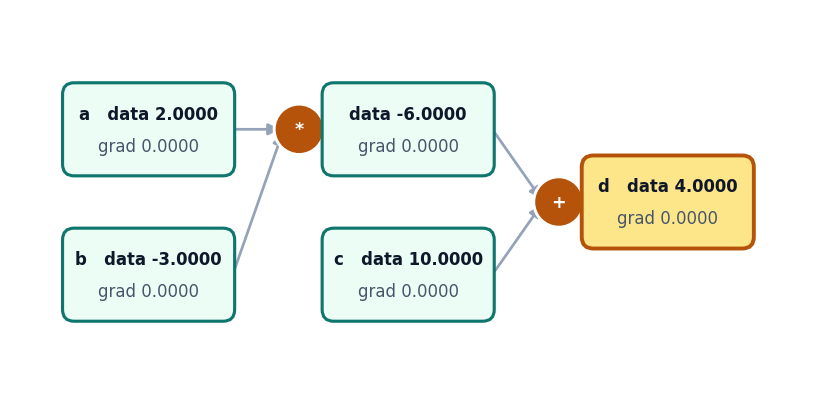

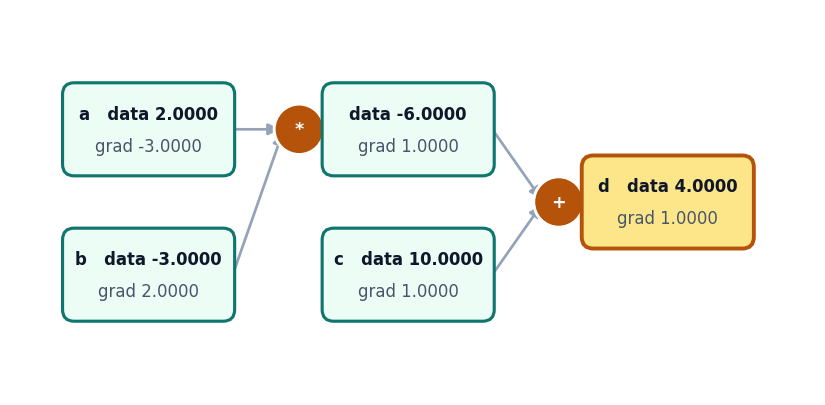

In [12]:
# el grafo de d = a*b + c, ANTES del backward (todos los grad en 0)
a = Value(2.0); b = Value(-3.0); c = Value(10.0)
d = a*b + c
draw_graph(d, names={"a": a, "b": b, "c": c, "d": d})

# ...y DESPUES: mira como los grad se llenan de la salida hacia las entradas
d.backward()
draw_graph(d, names={"a": a, "b": b, "c": c, "d": d})

<a name='3'></a>
## 3 - De neurona a red

Con `Value` funcionando, construimos las piezas de una red. Todo se apoya en las operaciones que ya implementaste:
- una **neurona** calcula un producto interno de sus pesos por la entrada, le suma un sesgo y aplica una activación;
- una **capa** es un conjunto de neuronas;
- un **MLP** (perceptrón multicapa) es una secuencia de capas.

La clave conceptual: Neuron ⊂ Layer ⊂ MLP, todo apilando Values, y una jerarquía de clases donde cada nivel sabe hacer dos cosas — calcularse hacia adelante (__call__) y entregar sus parámetros (parameters).

Te damos `Module` (una base con `zero_grad`/`parameters`), `Layer` y `MLP` hechos. Vos vas a completar el **forward de la neurona**.

In [13]:
class Module:
    # Una clase base de la que van a heredar Neuron, Layer y MLP.
    # Su único propósito es factorizar dos cosas que las tres comparten, para no repetirlas.
    def zero_grad(self):
      """
      zero_grad pone en cero el gradiente de todos los parámetros.
      Recorre self.parameters() (que cada subclase define) y a cada Value le fija grad = 0.0.
      Es imprescindible en el bucle de entrenamiento: como el backward acumula gradientes con +=,
      si no los reseteás antes de cada paso, se mezclan los de la iteración anterior con los nuevos.
      """
      for p in self.parameters():
            p.grad = 0.0

    def parameters(self):
      """
      placeholder, cada subclase implementará sus propios parámetros.
      """
      return []

class Neuron(Module):
  # Hereda de Module (así ya tiene zero_grad)
    def __init__(self, nin, nonlin=True):
        """Inicializa una neurona con pesos y sesgo aprendibles.

        Crea un peso por cada entrada —inicializado al azar para romper la
        simetría entre neuronas— y un sesgo en cero. Tanto los pesos como el
        sesgo son objetos ``Value``, de modo que forman parte del grafo de
        cómputo y el ``backward`` puede derivar respecto de ellos.

        Args:
            nin (int): Cantidad de entradas de la neurona, es decir la dimensión
                del vector de entrada ``x``. Se crea un peso por cada una.
            nonlin (bool): Si es ``True`` (por defecto), la neurona aplica la
                activación ``tanh`` en su salida; si es ``False``, la salida es
                lineal (afín), sin no linealidad.

        Atributos:
            w (list[Value]): Los ``nin`` pesos, con valores iniciales en [-1, 1].
            b (Value): El sesgo, inicializado en ``0.0``.
            nonlin (bool): Indica si se aplica ``tanh`` en el forward.
        """
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]  # un peso por entrada
        self.b = Value(0.0)                                          # sesgo
        self.nonlin = nonlin                                         # aplica tanh o no


    # __call__ lo completas en el Ejercicio 5
    # El forward de la neurona (la cuenta 𝜙(𝑤⊤𝑥+𝑏)) es justamente el ejercicio que completás vos

    def parameters(self):
        """
        Sobreescribe parameters: los parámetros de una neurona son una lista con sus pesos y su sesgo.
        self.w es una lista y [self.b] la vuelve lista para concatenar con +,
        devolviendo una sola lista de Values.
        Esto es lo que zero_grad y el update van a recorrer.
        """
        return self.w + [self.b]

class Layer(Module):
    """
    Una capa densa: un conjunto de neuronas que comparten la misma entrada.
    Representa una transformación de R^nin -> R^nout, aplicando ``nout``
    neuronas independientes (cada una con sus propios pesos y sesgo) al mismo
    vector de entrada. Todas las neuronas de la capa reciben la configuración
    que se pase por ``**kw`` (por ejemplo, ``nonlin``).

    Atributos:
        neurons (list[Neuron]): Las ``nout`` neuronas que componen la capa.
    """
    def __init__(self, nin, nout, **kw):
        self.neurons = [Neuron(nin, **kw) for _ in range(nout)]\

    def __call__(self, x):
        # El forward de la capa: le pasa la misma entrada x a cada neurona (n(x) invoca el __call__ de la neurona)
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        #Los parámetros de la capa son todos los parámetros de todas sus neuronas, aplanados en una sola lista.
        return [p for n in self.neurons for p in n.parameters()]

class MLP(Module):
    def __init__(self, nin, nouts):
        sizes = [nin] + nouts
        # nin → cuántos números entran a la red (la dimensión de entrada).
        # nouts = [n_ou1_1, n_out_2, n_out_3] → cuántas neuronas tiene cada capa (o sea, cuántos números salen de cada capa).
        # Ejemplo:
        # sizes = [ 3 ,  4 ,  4 ,  1 ]
        #           │    │    │    │
        #         entra  │    │   sale
        #               tras tras
        #              capa capa
        #                1    2


        # capas ocultas con tanh; la ultima capa lineal (nonlin=False)
        self.layers = [Layer(sizes[i], sizes[i+1], nonlin=(i != len(nouts)-1))
                       for i in range(len(nouts))]

        # sizes:   3     4     4     1
        #         └──┬──┘  └──┬──┘  └──┬──┘
        #         Layer   Layer   Layer
        #         (3, 4)  (4, 4)  (4, 1)

        #   sizes[0], sizes[1] = 3, 4 → Layer(3, 4)
        #   sizes[1], sizes[2] = 4, 4 → Layer(4, 4)
        #   sizes[2], sizes[3] = 4, 1 → Layer(4, 1)

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

print("Module, Neuron, Layer y MLP definidos (falta Neuron.__call__).")

Module, Neuron, Layer y MLP definidos (falta Neuron.__call__).


### Ejercicio 5 — El forward de una neurona (`Neuron.__call__`)

Una neurona calcula
$$a = \phi\Big(\sum_i w_i x_i + b\Big),$$
es decir: el **producto interno** de sus pesos por la entrada, más el sesgo, y después la activación $\phi$ (aquí `tanh` si `self.nonlin` es `True`, o nada si es `False`).

Completá `Neuron.__call__`.

> 💡 Truco cómodo: `sum((wi*xi for wi, xi in zip(self.w, x)), self.b)` arranca la suma en `self.b` y le agrega cada producto $w_i x_i$. Usa tu `__add__` y tu `__mul__`.

In [14]:
def neuron_call(self, x):
    ### EMPEZÁ TU CÓDIGO ACÁ ### (aprox. 2 lineas)
    ### TERMINÁ TU CÓDIGO ACÁ ###

Neuron.__call__ = neuron_call
print("Neuron.__call__ agregado.")

Neuron.__call__ agregado.


In [15]:
# TEST — no modifiques esta celda
# neurona LINEAL con pesos fijos: 0.5*2 + (-1.0)*3 + 0.25 = -1.75
n = Neuron(2, nonlin=False)
n.w = [Value(0.5), Value(-1.0)]; n.b = Value(0.25)
out = n([Value(2.0), Value(3.0)])
assert isinstance(out, Value)
assert abs(out.data - (-1.75)) < 1e-9, f"esperaba -1.75 y obtuve {out.data}"

# la misma neurona con tanh debe quedar en (-1, 1) y valer tanh(-1.75)
n.nonlin = True
out2 = n([Value(2.0), Value(3.0)])
assert abs(out2.data - math.tanh(-1.75)) < 1e-9
assert -1.0 < out2.data < 1.0

# el gradiente fluye hasta los pesos
out2.backward()
assert n.w[0].grad != 0.0, "el backward deberia poblar el gradiente de los pesos"
print("✓ Ejercicio 5 correcto.  lineal =", round(out.data,4), " | tanh =", round(out2.data,4))

✓ Ejercicio 5 correcto.  lineal = -1.75  | tanh = -0.9414


**Salida esperada:**
```
✓ Ejercicio 5 correcto.  lineal = -1.75  | tanh = -0.9414
```

<a name='4'></a>
## 4 - El bucle de entrenamiento

Ya tenemos todo para entrenar. Usamos un dataset diminuto: 4 ejemplos de 3 features, con objetivos $\pm 1$ (un problema de clasificación binaria de juguete). El modelo es un `MLP(3, [4, 4, 1])`: dos capas ocultas de 4 neuronas y una salida.

Corré la celda del dataset y después completá la función de entrenamiento.

In [16]:
# dataset de juguete (4 ejemplos, 3 features) y sus objetivos
xs = [[ 2.0,  3.0, -1.0],
      [ 3.0, -1.0,  0.5],
      [ 0.5,  1.0,  1.0],
      [ 1.0,  1.0, -1.0]]
ys = [1.0, -1.0, -1.0, 1.0]   # target: +1 / -1
print("Dataset listo:", len(xs), "ejemplos de", len(xs[0]), "features.")

Dataset listo: 4 ejemplos de 3 features.


### Ejercicio 6 — Un paso de entrenamiento

El corazón del aprendizaje profundo es este bucle, que se repite `n_steps` veces:

**forward → pérdida → `zero_grad` → `backward` → update**

Completá el cuerpo de `train`. Vas a:
1. calcular las predicciones (`forward`) y la **pérdida** (MSE: suma de $(\hat y - y)^2$);
2. poner los gradientes en **cero** (`model.zero_grad()`);
3. hacer `loss.backward()`;
4. **actualizar** cada parámetro: `p.data -= lr * p.grad`.

> ⚠️ **Dos trampas clásicas:**
> 1. Hay que hacer `zero_grad()` en **cada** paso: como el backward **acumula** (`+=`), si no reiniciás, se mezclan los gradientes de pasos anteriores.
> 2. El update toca `p.data`, **no** el grafo: `p.data -= lr * p.grad` modifica el número directamente.

In [17]:
def train(model, xs, ys, n_steps=120, lr=0.05):
    """Entrena un modelo con descenso por gradiente y devuelve la curva de pérdida.

    Repite ``n_steps`` veces el ciclo de aprendizaje supervisado sobre todo el
    dataset: forward (predicciones) → pérdida (MSE) → ``zero_grad`` → ``backward``
    → update de los parámetros. En cada paso, cada parámetro se actualiza en la
    dirección opuesta a su gradiente con ``p.data -= lr * p.grad``.

    Notas:
        - ``model.zero_grad()`` se llama en CADA paso, antes de ``backward``,
          porque el backward acumula gradientes (``+=``); sin resetear, se
          mezclarían con los de pasos anteriores.
        - El update modifica ``p.data`` directamente (aritmética sobre el número),
          no crea operaciones ``Value`` ni toca el grafo de cómputo.

    Args:
        model (Module): Modelo a entrenar (p. ej. un ``MLP``). Se usan
            ``model(x)`` para el forward, ``model.zero_grad()`` y
            ``model.parameters()``.
        xs (list): Entradas de entrenamiento; cada elemento es un ejemplo
            (p. ej. una lista de features).
        ys (list): Objetivos correspondientes a ``xs`` (un target por ejemplo).
        n_steps (int): Cantidad de pasos de entrenamiento (iteraciones del
            bucle). Por defecto 120.
        lr (float): Tasa de aprendizaje (tamaño del paso de descenso).
            Por defecto 0.05.

    Returns:
        list[float]: La pérdida (``loss.data``) de cada paso, en orden. Si el
        entrenamiento converge, la secuencia decrece hacia valores cercanos a 0.
    """
    losses = []
    for step in range(n_steps):
        ### EMPEZÁ TU CÓDIGO ACÁ ### (aprox. 6 lineas)
        ### TERMINÁ TU CÓDIGO ACÁ ###
        losses.append(loss.data)
    return losses

print("Funcion train definida.")

Funcion train definida.


nº de parametros: 41
perdida: 3.0929  ->  0.000000
predicciones: [1.0, -1.0, -1.0, 1.0]  | target: [1.0, -1.0, -1.0, 1.0]


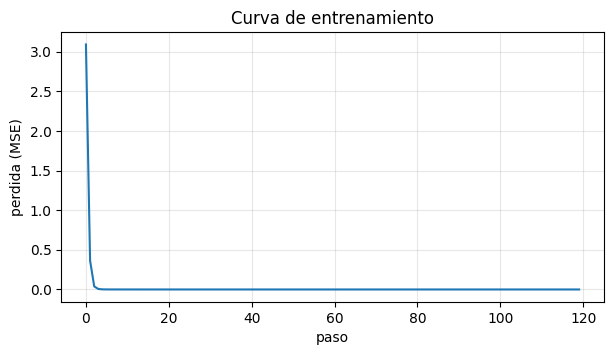

✓ Ejercicio 6 correcto: la red aprendio.


In [18]:
# TEST — no modifiques esta celda
random.seed(1337)
model = MLP(3, [4, 4, 1])
print("nº de parametros:", len(model.parameters()))
losses = train(model, xs, ys, n_steps=120, lr=0.05)

assert losses[-1] < losses[0], "la perdida deberia bajar"
assert losses[-1] < 0.05, f"tras 120 pasos la perdida deberia ser chica; dio {losses[-1]:.4f}"
preds = [round(model(x).data, 2) for x in xs]
print(f"perdida: {losses[0]:.4f}  ->  {losses[-1]:.6f}")
print("predicciones:", preds, " | target:", ys)

plt.figure(figsize=(7,3.5))
plt.plot(losses)
plt.xlabel("paso"); plt.ylabel("perdida (MSE)"); plt.title("Curva de entrenamiento")
plt.grid(alpha=0.3); plt.show()
print("✓ Ejercicio 6 correcto: la red aprendio.")

**Salida esperada** (los números pueden variar un poquito por el hardware, pero la pérdida baja casi a cero y las predicciones se acercan a los targets):
```
nº de parametros: 41
perdida: 3.0929  ->  0.000000
predicciones: [1.0, -1.0, -1.0, 1.0]  | target: [1.0, -1.0, -1.0, 1.0]
✓ Ejercicio 6 correcto: la red aprendio.
```
Y una curva de pérdida que **decrece** hacia cero. 🎉

<a name='5'></a>
## 5 - (Opcional) Extendé el motor

Agregá más operaciones a tu motor y volvé a verificarlas. Ya tenés `tanh`; ahora sumá `exp`.

### Ejercicio 7 — La exponencial (`exp`)

La derivada de la exponencial es notablemente simple: $\dfrac{d}{dz}e^{z} = e^{z}$, o sea, **la propia salida**. Completá `exp`.

In [19]:
def exp(self):
    ### EMPEZÁ TU CÓDIGO ACÁ ### (aprox. 5 lineas)
    ### TERMINÁ TU CÓDIGO ACÁ ###

Value.exp = exp
print("exp agregada a Value.")

exp agregada a Value.


In [20]:
# TEST — no modifiques esta celda: gradient check de exp
x = Value(0.7)
y = x.exp()
assert abs(y.data - math.exp(0.7)) < 1e-9
y.backward()
h = 1e-6
num = (math.exp(0.7 + h) - math.exp(0.7 - h)) / (2*h)
assert abs(x.grad - num) < 1e-4, "el gradiente de exp debe coincidir con el numerico"
print("✓ Ejercicio 7 correcto.  exp(0.7) =", round(y.data,4), " | grad analitico", round(x.grad,4), "~ numerico", round(num,4))

✓ Ejercicio 7 correcto.  exp(0.7) = 2.0138  | grad analitico 2.0138 ~ numerico 2.0138


**Salida esperada:**
```
✓ Ejercicio 7 correcto.  exp(0.7) = 2.0138  | grad analitico 2.0138 ~ numerico 2.0138
```

### Más ideas para seguir
- Derivá a mano el gradiente local de `tanh` y de `exp` y confirmá que coincide con lo que programaste.
- Agregá `relu` (derivada: 1 si $z>0$, 0 si no) y comparala con `tanh` en el entrenamiento.
- Probá cambiar `lr` (tasa de aprendizaje): ¿qué pasa si es muy grande? ¿y muy chica?
- Entrená con más pasos y observá la curva de pérdida.

---
## Cierre

Escribiste, en unas cien líneas, un **motor de diferenciación automática en modo reverso** y entrenaste una red con él. Conceptualmente, es **el mismo** mecanismo con el que se entrena un LLM: lo único que cambia es la **escala** —miles de millones de parámetros y un dataset de internet— y las operaciones (atención, normalización), que son más `Value`s en un grafo más grande.

**Para seguir:**
- *micrograd* de Andrej Karpathy y su video "The spelled-out intro to neural networks and backpropagation".
- La documentación de `torch.autograd`: la misma idea, a escala industrial.

